In [1]:
"""
PASSO 3b — Seleção de Atributos (Correlação de Pearson + Mutual Information).

Pipeline de 2 estágios:
    Estágio 1 — Remoção de redundância:
        Calcula a correlação de Pearson entre todos os pares de features
        (pooling de todas as ações). Se |ρ| > CORR_THRESHOLD, remove a
        feature com menor Mutual Information com o label.

    Estágio 2 — Seleção por relevância:
        Calcula a Mutual Information entre cada feature remanescente e o
        label. Seleciona as top-k features mais informativas.

Saída:
    - FeatureSelection_Report.csv: relatório com MI e status de cada feature
    - FeatureSelection_Selected.txt: lista das features selecionadas
    - {Code}_DatasetNew_MI.csv: datasets com apenas as features selecionadas
    - FeatureSelection_Correlation_Matrix.csv: matriz de correlação completa
    - FeatureSelection_MI_Ranking.csv: ranking por MI

Uso:
    python 03b_feature_selection.py
"""

from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.feature_selection import mutual_info_classif
import warnings

warnings.filterwarnings("ignore")

# ===================== CONFIGURAÇÃO =====================
BASE_DIR = Path(r"C:\Users\Rodrigo\Desktop\Replicando para B3_2\B3ICS")
SEC_NAMES = BASE_DIR / ".NewB3_pruned.csv"

# Estágio 1: limiar de correlação para remoção de redundância
CORR_THRESHOLD = 0.85

# Estágio 2: número de features a selecionar (None = automático via cotovelo)
TOP_K = None  # Se None, usa método do cotovelo para determinar k

# Seed para reproducibilidade
RANDOM_STATE = 42
# ========================================================


def load_all_data(base_dir, sec_names_path):
    """
    Carrega e concatena os DatasetNew de todas as ações.
    Retorna X (features), y (labels) e a lista de feature_cols.
    """
    codes_df = pd.read_csv(sec_names_path, dtype=str, encoding="utf-8-sig")
    codes = codes_df["Code"].str.strip().str.upper().tolist()

    all_X = []
    all_y = []

    for code in tqdm(codes, desc="Carregando dados"):
        infile = base_dir / f"{code}_DatasetNew.csv"
        if not infile.exists():
            continue

        try:
            df = pd.read_csv(infile, encoding="utf-8-sig")
            feature_cols = df.columns[1:-1].tolist()
            X = df[feature_cols].values.astype(float)
            y = df[df.columns[-1]].values.astype(int)

            # Remover linhas com NaN
            mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y.astype(float))
            if mask.sum() > 0:
                all_X.append(X[mask])
                all_y.append(y[mask])
        except Exception:
            continue

    X_pool = np.vstack(all_X)
    y_pool = np.concatenate(all_y)

    return X_pool, y_pool, feature_cols


def stage1_correlation_filter(X, y, feature_cols, threshold):
    """
    Estágio 1: Remove features redundantes por correlação de Pearson.
    Quando |ρ| > threshold entre duas features, remove a que tem menor MI com y.
    """
    print(f"\n{'='*60}")
    print(f"ESTÁGIO 1: Remoção por correlação (|ρ| > {threshold})")
    print(f"{'='*60}")

    n_features = len(feature_cols)
    print(f"  Features iniciais: {n_features}")

    # Calcular matriz de correlação
    corr_matrix = np.corrcoef(X, rowvar=False)
    corr_df = pd.DataFrame(corr_matrix, index=feature_cols, columns=feature_cols)

    # Salvar matriz de correlação
    corr_df.to_csv(BASE_DIR / "FeatureSelection_Correlation_Matrix.csv",
                   encoding="utf-8-sig")

    # Calcular MI de todas as features (para decidir qual remover nos pares)
    print("  Calculando Mutual Information para desempate...")
    mi_all = mutual_info_classif(X, y, discrete_features=False,
                                 random_state=RANDOM_STATE, n_neighbors=5)
    mi_dict = dict(zip(feature_cols, mi_all))

    # Identificar pares altamente correlacionados
    removed = set()
    pairs_found = []

    for i in range(n_features):
        if feature_cols[i] in removed:
            continue
        for j in range(i + 1, n_features):
            if feature_cols[j] in removed:
                continue
            rho = abs(corr_matrix[i, j])
            if rho > threshold:
                fi, fj = feature_cols[i], feature_cols[j]
                mi_i, mi_j = mi_dict[fi], mi_dict[fj]
                # Remove a de menor MI
                if mi_i >= mi_j:
                    removed.add(fj)
                    pairs_found.append((fi, fj, rho, f"removida: {fj} (MI={mi_j:.4f} < {mi_i:.4f})"))
                else:
                    removed.add(fi)
                    pairs_found.append((fi, fj, rho, f"removida: {fi} (MI={mi_i:.4f} < {mi_j:.4f})"))

    print(f"\n  Pares com |ρ| > {threshold}: {len(pairs_found)}")
    for f1, f2, rho, desc in pairs_found:
        print(f"    {f1:>10} x {f2:<10}  ρ={rho:.3f}  → {desc}")

    surviving = [f for f in feature_cols if f not in removed]
    print(f"\n  Features removidas: {len(removed)}")
    print(f"  Features sobreviventes: {len(surviving)}")

    return surviving, removed, mi_dict, pairs_found


def stage2_mutual_information(X, y, feature_cols, surviving, top_k=None):
    """
    Estágio 2: Seleciona top-k features por Mutual Information.
    Se top_k=None, usa método do cotovelo.
    """
    print(f"\n{'='*60}")
    print(f"ESTÁGIO 2: Seleção por Mutual Information")
    print(f"{'='*60}")

    # Índices das features sobreviventes
    surv_idx = [feature_cols.index(f) for f in surviving]
    X_surv = X[:, surv_idx]

    # Calcular MI
    print("  Calculando Mutual Information...")
    mi_scores = mutual_info_classif(X_surv, y, discrete_features=False,
                                    random_state=RANDOM_STATE, n_neighbors=5)

    # Ranking
    mi_ranking = pd.DataFrame({
        "Feature": surviving,
        "MI": mi_scores,
    }).sort_values("MI", ascending=False).reset_index(drop=True)
    mi_ranking["Rank"] = range(1, len(mi_ranking) + 1)

    print(f"\n  Ranking por Mutual Information:")
    for _, row in mi_ranking.iterrows():
        print(f"    {row['Rank']:2d}. {row['Feature']:>10}  MI={row['MI']:.4f}")

    # Determinar k
    if top_k is None:
        # Método do cotovelo: seleciona até onde a MI cai abaixo de 50% da máxima
        # ou até onde a queda percentual entre consecutivos é > 50%
        mi_sorted = mi_ranking["MI"].values
        mi_max = mi_sorted[0]

        if mi_max == 0:
            top_k = len(surviving)
        else:
            # Critério: MI >= 10% da MI máxima
            threshold_mi = mi_max * 0.10
            above = (mi_sorted >= threshold_mi).sum()
            top_k = max(above, 5)  # mínimo 5 features

        print(f"\n  Método automático: MI máxima={mi_max:.4f}, limiar 10%={mi_max*0.10:.4f}")
        print(f"  → top_k determinado automaticamente: {top_k}")
    else:
        top_k = min(top_k, len(surviving))
        print(f"\n  → top_k definido manualmente: {top_k}")

    selected = mi_ranking.head(top_k)["Feature"].tolist()

    print(f"\n  Features selecionadas ({len(selected)}):")
    for i, f in enumerate(selected):
        mi_val = mi_ranking[mi_ranking["Feature"] == f]["MI"].values[0]
        print(f"    {i+1:2d}. {f:>10}  MI={mi_val:.4f}")

    return selected, mi_ranking


def create_filtered_datasets(base_dir, sec_names_path, selected_features):
    """
    Cria novos DatasetNew com apenas as features selecionadas.
    Salva como {Code}_DatasetNew_MI.csv.
    """
    print(f"\n{'='*60}")
    print("Gerando datasets filtrados")
    print(f"{'='*60}")

    codes_df = pd.read_csv(sec_names_path, dtype=str, encoding="utf-8-sig")
    codes = codes_df["Code"].str.strip().str.upper().tolist()

    n_created = 0
    for code in tqdm(codes, desc="Gerando DatasetNew_MI"):
        infile = base_dir / f"{code}_DatasetNew.csv"
        outfile = base_dir / f"{code}_DatasetNew_MI.csv"

        if not infile.exists():
            continue

        try:
            df = pd.read_csv(infile, encoding="utf-8-sig")
            date_col = df.columns[0]
            label_col = df.columns[-1]

            # Verificar quais features selecionadas existem neste arquivo
            available = [f for f in selected_features if f in df.columns]
            if not available:
                continue

            # Montar DataFrame filtrado
            out = pd.DataFrame()
            out[date_col] = df[date_col]
            for col in available:
                out[col] = df[col]
            out[label_col] = df[label_col]

            out.to_csv(outfile, index=False, encoding="utf-8-sig")
            n_created += 1
        except Exception:
            continue

    print(f"  Criados: {n_created} arquivos _DatasetNew_MI.csv")
    print(f"  Colunas: Date + {len(selected_features)} features + Label = {len(selected_features) + 2}")

    return n_created


def main():
    print("=" * 60)
    print("PASSO 3b: Seleção de Atributos")
    print(f"  Correlação de Pearson (|ρ| > {CORR_THRESHOLD}) + Mutual Information")
    print("=" * 60)

    # Carregar dados de todas as ações (pooling)
    X_pool, y_pool, feature_cols = load_all_data(BASE_DIR, SEC_NAMES)
    print(f"\nDados carregados:")
    print(f"  Amostras totais: {X_pool.shape[0]:,}")
    print(f"  Features: {X_pool.shape[1]}")
    print(f"  Label: {np.bincount(y_pool)} (0s / 1s)")

    # Estágio 1: Correlação
    surviving, removed, mi_dict_all, pairs = stage1_correlation_filter(
        X_pool, y_pool, feature_cols, CORR_THRESHOLD)

    # Estágio 2: Mutual Information
    selected, mi_ranking = stage2_mutual_information(
        X_pool, y_pool, feature_cols, surviving, TOP_K)

    # Salvar relatório completo
    report = []
    for f in feature_cols:
        status = "removida_correlacao" if f in removed else \
                 ("selecionada" if f in selected else "removida_MI")
        mi_val = mi_dict_all.get(f, np.nan)
        report.append({"Feature": f, "MI_global": mi_val, "Status": status})

    report_df = pd.DataFrame(report).sort_values("MI_global", ascending=False)
    report_df.to_csv(BASE_DIR / "FeatureSelection_Report.csv",
                     index=False, encoding="utf-8-sig")

    # Salvar ranking MI
    mi_ranking.to_csv(BASE_DIR / "FeatureSelection_MI_Ranking.csv",
                      index=False, encoding="utf-8-sig")

    # Salvar lista de features selecionadas
    with open(BASE_DIR / "FeatureSelection_Selected.txt", "w") as f:
        for feat in selected:
            f.write(feat + "\n")

    # Criar datasets filtrados
    n_created = create_filtered_datasets(BASE_DIR, SEC_NAMES, selected)

    # Resumo final
    print(f"\n{'='*60}")
    print("RESUMO FINAL")
    print(f"{'='*60}")
    print(f"  Features originais:            {len(feature_cols)}")
    print(f"  Removidas por correlação:      {len(removed)}")
    print(f"  Sobreviventes pós-correlação:  {len(surviving)}")
    print(f"  Selecionadas por MI:           {len(selected)}")
    print(f"  Datasets _MI.csv criados:      {n_created}")
    print(f"\n  Arquivos gerados:")
    print(f"    - FeatureSelection_Report.csv")
    print(f"    - FeatureSelection_MI_Ranking.csv")
    print(f"    - FeatureSelection_Correlation_Matrix.csv")
    print(f"    - FeatureSelection_Selected.txt")
    print(f"    - {{Code}}_DatasetNew_MI.csv ({n_created} arquivos)")


if __name__ == "__main__":
    main()

PASSO 3b: Seleção de Atributos
  Correlação de Pearson (|ρ| > 0.85) + Mutual Information


Carregando dados: 100%|██████████| 246/246 [00:04<00:00, 56.45it/s]



Dados carregados:
  Amostras totais: 197,500
  Features: 44
  Label: [ 85466 112034] (0s / 1s)

ESTÁGIO 1: Remoção por correlação (|ρ| > 0.85)
  Features iniciais: 44
  Calculando Mutual Information para desempate...

  Pares com |ρ| > 0.85: 15
            WR x RSV         ρ=0.989  → removida: RSV (MI=0.0094 < 0.0098)
            WR x Kvalue      ρ=0.890  → removida: Kvalue (MI=0.0011 < 0.0098)
            WR x Jvalue      ρ=0.949  → removida: Jvalue (MI=0.0002 < 0.0098)
       BandPer x CCI         ρ=0.877  → removida: BandPer (MI=0.0020 < 0.0038)
           DIS x MOM         ρ=0.940  → removida: DIS (MI=0.0018 < 0.0084)
           DIS x ROC         ρ=0.948  → removida: DIS (MI=0.0018 < 0.0058)
           DIS x Return      ρ=0.922  → removida: DIS (MI=0.0018 < 0.0062)
           MAO x TRIX        ρ=0.850  → removida: TRIX (MI=0.0005 < 0.0015)
           MAO x MACD        ρ=0.936  → removida: MACD (MI=0.0008 < 0.0015)
           MOM x ROC         ρ=0.925  → removida: ROC (MI=0.0058 < 

Gerando DatasetNew_MI: 100%|██████████| 246/246 [00:16<00:00, 15.01it/s]

  Criados: 246 arquivos _DatasetNew_MI.csv
  Colunas: Date + 23 features + Label = 25

RESUMO FINAL
  Features originais:            44
  Removidas por correlação:      13
  Sobreviventes pós-correlação:  31
  Selecionadas por MI:           23
  Datasets _MI.csv criados:      246

  Arquivos gerados:
    - FeatureSelection_Report.csv
    - FeatureSelection_MI_Ranking.csv
    - FeatureSelection_Correlation_Matrix.csv
    - FeatureSelection_Selected.txt
    - {Code}_DatasetNew_MI.csv (246 arquivos)


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/cotovelo_mi.pdf'

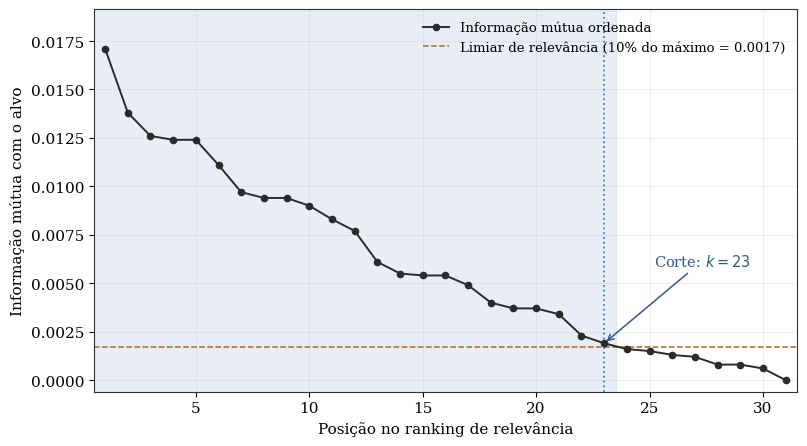

In [2]:
"""
Gera o grafico do cotovelo (elbow) da Informacao Mutua ordenada.
Valores extraidos do ranking do notebook 03b_feature_selection (Estagio 2).

O corte adotado foi: MI >= 10% da MI maxima -> top_k = 23.
"""
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------------------------------------------------------
# Ranking de MI das 31 features sobreviventes ao Estagio 1
# (feature, MI), na ordem decrescente do notebook
# ---------------------------------------------------------------
ranking = [
    ("OBV", 0.0171), ("AD", 0.0138), ("EOM", 0.0126), ("FI", 0.0124),
    ("RSI", 0.0124), ("NCO", 0.0111), ("VMA", 0.0097), ("WR", 0.0094),
    ("VOLA", 0.0094), ("Ret", 0.0090), ("MOM", 0.0083), ("PSY", 0.0077),
    ("RMI", 0.0061), ("CMF", 0.0055), ("NBIAS", 0.0054), ("SMA_5", 0.0054),
    ("ATR", 0.0049), ("MFI", 0.0040), ("CCI", 0.0037), ("MI", 0.0037),
    ("Sigma", 0.0034), ("CO", 0.0023), ("SONAR", 0.0019), ("ADX", 0.0016),
    ("MAO", 0.0015), ("SROC", 0.0013), ("VROC", 0.0012), ("BandWid", 0.0008),
    ("Dvalue", 0.0008), ("PO", 0.0006), ("VOS", 0.0000),
]

features = [r[0] for r in ranking]
mi = [r[1] for r in ranking]
ranks = list(range(1, len(ranking) + 1))

mi_max = mi[0]
threshold = 0.10 * mi_max          # limiar de 10% da MI maxima
top_k = sum(1 for v in mi if v >= threshold)   # = 23

# ---------------------------------------------------------------
# Estetica academica (sobria, escala de cinza + 1 destaque)
# ---------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
})

fig, ax = plt.subplots(figsize=(8.2, 4.6))

# Curva de MI ordenada
ax.plot(ranks, mi, marker="o", markersize=4.5, linewidth=1.4,
        color="#2b2b2b", zorder=3, label="Informação mútua ordenada")

# Regiao selecionada (sombreamento ate o corte)
ax.axvspan(0.5, top_k + 0.5, color="#4a7bbd", alpha=0.12, zorder=0)

# Linha do limiar de 10%
ax.axhline(threshold, color="#b5651d", linestyle="--", linewidth=1.1,
           zorder=2, label=f"Limiar de relevância (10% do máximo = {threshold:.4f})")

# Linha vertical do corte (k = 23)
ax.axvline(top_k, color="#4a7bbd", linestyle=":", linewidth=1.3, zorder=2)
ax.annotate(f"Corte: $k = {top_k}$",
            xy=(top_k, mi[top_k - 1]),
            xytext=(top_k + 2.2, mi[top_k - 1] + 0.0040),
            fontsize=10.5, color="#2f5a8f",
            arrowprops=dict(arrowstyle="->", color="#2f5a8f", lw=1.1))

# Marcar o "joelho" visual da curva
ax.set_xlabel("Posição no ranking de relevância")
ax.set_ylabel("Informação mútua com o alvo")
ax.set_xlim(0.5, len(ranking) + 0.5)
ax.set_ylim(-0.0006, mi_max * 1.12)
ax.grid(True, linestyle="-", linewidth=0.4, alpha=0.35, zorder=0)
ax.legend(frameon=False, fontsize=9.5, loc="upper right")

fig.tight_layout()
fig.savefig("/home/claude/cotovelo_mi.pdf", bbox_inches="tight")
fig.savefig("/home/claude/cotovelo_mi.png", dpi=200, bbox_inches="tight")

print(f"MI maxima      : {mi_max:.4f}")
print(f"Limiar (10%)   : {threshold:.4f}")
print(f"top_k (>= 10%) : {top_k}")
print("Figuras geradas: cotovelo_mi.pdf / cotovelo_mi.png")